# Stochastic Heat Equation — Statistical Analysis

We study the stochastic heat equation on $[0,1]$ with Dirichlet boundary conditions,

$$\mathrm{d}u = d\,u_{xx}\,\mathrm{d}t + g(t)\,\mathrm{d}W_t,$$

solved spectrally: in the sine basis the equation decouples into a system of
Ornstein--Uhlenbeck SDEs for the modal coefficients, which we evolve in time and
then reconstruct via the inverse discrete sine transform.

This notebook collects two statistical experiments on that solver:

1. **Monte-Carlo statistics** — the empirical mean and $\pm1,\pm2$ standard-deviation
   bands of $u(x)$ at two fixed times.
2. **Covariance comparison** — the difference between using the *exact* one-step
   Ornstein--Uhlenbeck noise variance and a naive flat $\sigma^2\,\mathrm{d}t$ variance.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)
from scipy.fft import dst, idst

## 1. Monte-Carlo mean and standard deviation

### Spectral solver

`heat_spectral` advances the modal coefficients $a_k$ over a uniform time grid.
At each step every mode decays deterministically and is then kicked by Gaussian
noise with covariance $\text{var}\cdot\mathrm{d}t\cdot Q$, where $Q$ controls how
the energy is distributed across modes. The solution $u$ is recovered on the
spatial grid by the inverse sine transform.

In [2]:
def heat_spectral(u0, T, Nt, Nx, K_modes, rng, d, var, g, Q):
    """Spectral solver for  du = d*u_xx dt + g(t) dW_t  on [0, 1], Dirichlet BCs.

    Parameters
    ----------
    u0       : callable, initial profile u0(x) on [0, 1]
    T        : final time
    Nt, Nx   : number of time steps / spatial intervals
    K_modes  : number of retained sine modes
    rng      : numpy Generator
    d        : diffusivity
    var      : overall noise variance scale
    g        : callable, time modulation g(t) of the noise
    Q        : (K_modes, K_modes) modal noise covariance

    Returns
    -------
    X, Y : (Nx+1, Nt) meshgrids of time and space
    u    : (Nt, Nx+1) solution array
    """
    u = np.zeros((Nt, Nx + 1))
    u[0] = [u0(x / Nx) for x in range(Nx + 1)]

    x = np.linspace(0, T, Nt)
    y = np.linspace(0, 1, Nx + 1)
    X, Y = np.meshgrid(x, y)

    dt = T / Nt

    # Project the initial condition onto the sine basis.
    a = dst(u[0], n=K_modes, type=1, norm='ortho')

    for t in range(Nt):
        wt = rng.multivariate_normal(np.zeros(K_modes), var * dt * Q)
        # Each mode k decays at rate (k*pi)^2 and is kicked by g(t)*wt[k].
        a = [a[k] * np.exp(-2 * d * ((k + 1) * np.pi) ** 2 * dt) + g(t * dt) * wt[k]
             for k in range(K_modes)]
        u[t] = idst(a, n=Nx + 1, type=1, norm='ortho')

    return X, Y, u

### Experiment setup

We take a smooth bump initial profile, constant noise modulation $g\equiv1$, and
the identity covariance $Q=I$ (space–time white noise — every mode kicked equally).

In [3]:
K_modes = 50

def u0(x):
    return 4 * x * (1 - x)   # smooth bump, zero at both ends

def g(t):
    return 1                 # constant-in-time noise scaling

Q = np.identity(K_modes)     # space-time white noise

In [4]:
rng = np.random.default_rng(67)

T, Nt, Nx = 5.0, 1000, 50    # run to t = 5 so both t = 2 and t = 5 fall inside one run
N = 300                      # number of Monte-Carlo samples

t_grid = np.linspace(0, T, Nt)
i2 = np.argmin(np.abs(t_grid - 2))   # time-row nearest t = 2
i5 = np.argmin(np.abs(t_grid - 5))   # time-row nearest t = 5

### Sampling

Run `N` independent simulations and record the spatial profile at $t=2$ and $t=5$.
(With `N = 300` this takes a couple of minutes; lower `N` for a quick check.)

In [5]:
samples_t2 = np.zeros((N, Nx + 1))
samples_t5 = np.zeros((N, Nx + 1))

for i in range(N):
    _, _, u = heat_spectral(u0, T, Nt, Nx, K_modes, rng, d=0.01, var=0.5, g=g, Q=Q)
    samples_t2[i] = u[i2]
    samples_t5[i] = u[i5]

In [6]:
mean_t2 = samples_t2.mean(axis=0)
std_t2 = samples_t2.std(axis=0, ddof=1)

mean_t5 = samples_t5.mean(axis=0)
std_t5 = samples_t5.std(axis=0, ddof=1)

### Result

The empirical mean (blue) sits inside its $\pm1$ (green) and $\pm2$ (red) standard-deviation
bands. By $t=5$ the mean has diffused toward zero while the noise has built up a
roughly uniform spread across the domain.

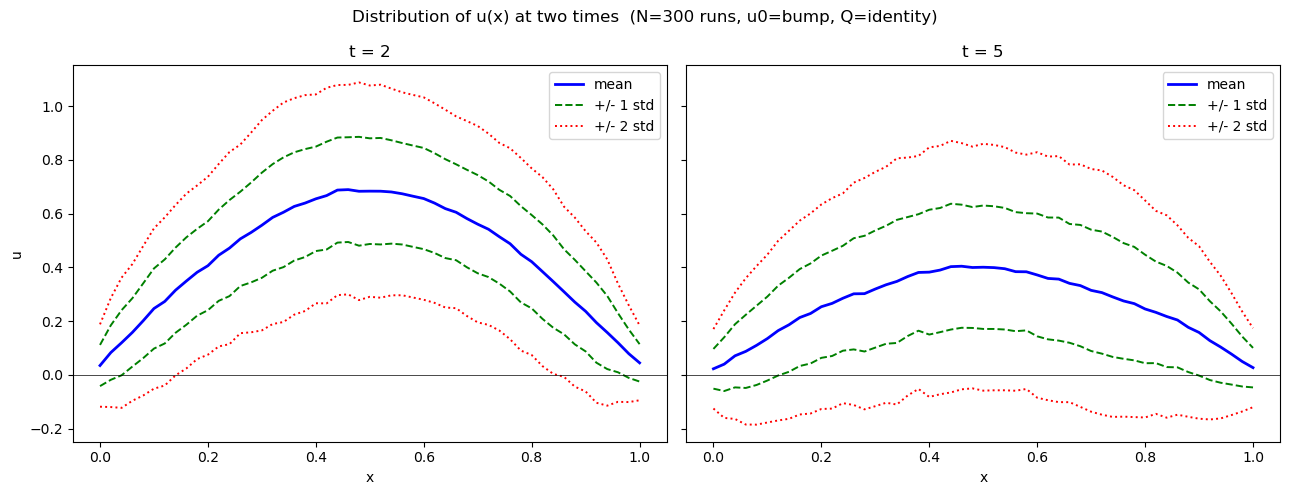

In [7]:
x = np.linspace(0, 1, Nx + 1)
fig, axs = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, mean, std, tt in [(axs[0], mean_t2, std_t2, 2), (axs[1], mean_t5, std_t5, 5)]:
    ax.plot(x, mean, 'b-', lw=2, label='mean')
    ax.plot(x, mean + std, 'g--', lw=1.4, label='+/- 1 std')
    ax.plot(x, mean - std, 'g--', lw=1.4)
    ax.plot(x, mean + 2 * std, 'r:', lw=1.4, label='+/- 2 std')
    ax.plot(x, mean - 2 * std, 'r:', lw=1.4)
    ax.axhline(0, color='k', lw=0.5)
    ax.set(xlabel='x', title=f't = {tt}')
    ax.legend()

axs[0].set_ylabel('u')
fig.suptitle(f'Distribution of u(x) at two times  (N={N} runs, u0=bump, Q=identity)')
plt.tight_layout()
plt.savefig('distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Exact vs naive noise covariance

When the modal SDEs are integrated exactly over a step, the noise kick for mode $k$
has variance

$$q_k = \text{var}\cdot\frac{1 - e^{-2\lambda_k\,\mathrm{d}t}}{2\lambda_k},\qquad \lambda_k = d\,(k\pi)^2,$$

rather than the naive flat value $\text{var}\cdot\mathrm{d}t$ used above. Here we run the
solver with both choices on the *same* noise stream and compare the resulting surfaces.

In [8]:
def init(x):
    return 5 * x * (x - 1) * math.sin(23 * x)   # wiggly initial profile

def g(x):
    return 1

def var_diag_exact(K, d, dt, var):
    """Exact one-step Ornstein-Uhlenbeck noise variance per mode (Q = I)."""
    k = np.arange(1, K + 1)
    lam = d * (k * np.pi) ** 2
    return var * (1.0 - np.exp(-2.0 * lam * dt)) / (2.0 * lam)

def var_diag_identity(K, d, dt, var):
    """Naive flat variance var*dt for every mode."""
    return var * dt * np.ones(K)


def heat_spectral_diag(u0, T, Nt, Nx, rng, K_modes, d, g, var_diag):
    """Spectral solver driven by a diagonal per-mode variance vector.

    Using a fixed seed makes the standard-normal innovations identical across
    runs, so two variance choices can be compared on matched noise."""
    dt = T / Nt
    x = np.linspace(0, T, Nt)
    y = np.linspace(0, 1, Nx + 1)
    X, Y = np.meshgrid(x, y)

    k = np.arange(1, K_modes + 1)
    decay = np.exp(-d * (k * np.pi) ** 2 * dt)
    std = np.sqrt(var_diag)

    ic = np.array([u0(j / Nx) for j in range(Nx + 1)])
    u = np.zeros((Nt, Nx + 1))
    u[0] = ic
    a = dst(ic, n=K_modes, type=1, norm='ortho')

    for t in range(1, Nt):
        w = rng.standard_normal(K_modes) * std   # same seed -> matched innovations
        a = a * decay + g((t - 1) * dt) * w
        u[t] = idst(a, n=Nx + 1, type=1, norm='ortho')

    return X, Y, u

In [9]:
T, Nt, Nx, K_modes, d, var = 5, 1000, 50, 50, 0.01, 0.5
seed = 67
u0 = init
dt = T / Nt

X, Y, u_exact = heat_spectral_diag(u0, T, Nt, Nx, np.random.default_rng(seed),
                                   K_modes, d, g, var_diag_exact(K_modes, d, dt, var))
_, _, u_ident = heat_spectral_diag(u0, T, Nt, Nx, np.random.default_rng(seed),
                                   K_modes, d, g, var_diag_identity(K_modes, d, dt, var))
u_diff = u_exact - u_ident

### Result

The exact and naive surfaces look almost identical; their difference (right panel,
note the much smaller vertical scale) is tiny, confirming that for these parameters
the flat $\text{var}\cdot\mathrm{d}t$ approximation is a reasonable stand-in for the exact
OU step.

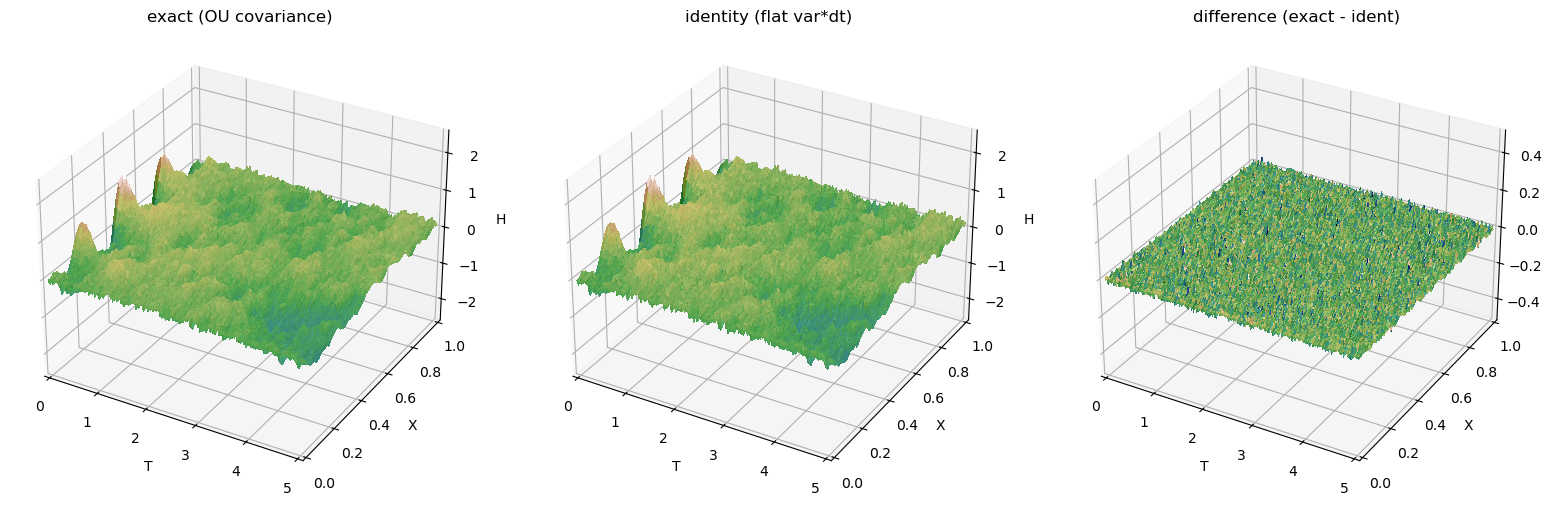

max|exact - identity| = 0.04940789763759201


In [10]:
fig, axs = plt.subplots(nrows=1, ncols=3, subplot_kw=dict(projection='3d'), figsize=(16, 5))
ls = col.LightSource(270, 45)

def show(ax, u, title, zlim):
    rgb = ls.shade(u.T, cmap=cm.gist_earth, vert_exag=0.1, blend_mode='soft')
    ax.plot_surface(X, Y, u.T, rstride=1, cstride=1, facecolors=rgb,
                    linewidth=0, antialiased=False, shade=False)
    ax.set(xlim=(0, T), ylim=(0, 1), zlim=zlim, xlabel='T', ylabel='X', zlabel='H')
    ax.set_title(title)

show(axs[0], u_exact, "exact (OU covariance)",      (-2.5, 2.5))
show(axs[1], u_ident, "identity (flat var*dt)",     (-2.5, 2.5))
show(axs[2], u_diff,  "difference (exact - ident)", (-0.5, 0.5))

plt.tight_layout()
plt.savefig('exact_vs_identity.png', dpi=120, bbox_inches='tight')
plt.show()
print("max|exact - identity| =", np.abs(u_diff).max())